# EP1 — StreamView Analytics
## Limpieza y Análisis Exploratorio (EDA) — Dataset `Data_Movies`

**Curso:** ADY1104 – Visualización de Datos  
**Caso:** StreamView Analytics — Evaluación Parcial I (Semana 5)

### Problema de negocio
StreamView Analytics dispone de un amplio catálogo cinematográfico, pero la cantidad y diversidad de contenidos dificulta identificar qué géneros, mercados y películas presentan mayor atractivo. El análisis busca transformar los datos del catálogo en indicadores y visualizaciones que permitan detectar patrones y contenidos destacados para apoyar decisiones de priorización y promoción.

### Pregunta central
> **¿Qué características del catálogo permiten identificar contenidos con mayor atractivo y potencial de priorización para StreamView Analytics?**

### Preguntas de análisis
1. ¿Qué géneros tienen mayor presencia en el catálogo?
2. ¿Qué géneros presentan mayor popularidad promedio?
3. ¿Qué países concentran la producción del catálogo?
4. ¿Qué películas destacan por popularidad y valoración?
5. ¿Qué oportunidades se observan entre presupuesto e ingresos?

### Alcance
Este notebook documenta la revisión de calidad, las transformaciones justificadas y el EDA del dataset **Netflix Movies Detailed up to 2025**. El archivo original no se modifica; se trabaja sobre una copia en memoria y se exporta un CSV limpio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ============================================================
# BUSCAR DATASET
# ============================================================
BASE_DIR = Path.cwd()

# Si el notebook se ejecuta desde /notebooks, sube un nivel.
# Si se ejecuta desde la raíz del proyecto, usa la carpeta actual.
if (BASE_DIR / 'data').exists():
    PROJECT_DIR = BASE_DIR
elif (BASE_DIR.parent / 'data').exists():
    PROJECT_DIR = BASE_DIR.parent
else:
    raise FileNotFoundError(
        f'No se encontró la carpeta data. Carpeta actual: {BASE_DIR}'
    )

DATA_DIR = PROJECT_DIR / 'data'
dataset_path = DATA_DIR / 'netflix_movies_detailed_up_to_2025.csv'

print('Carpeta actual:')
print(BASE_DIR)
print('\nBuscando dataset en:')
print(dataset_path)

if not dataset_path.exists():
    raise FileNotFoundError(
        f'No se encontró el dataset en:\n{dataset_path}\n'
        'Verifica que el archivo esté dentro de la carpeta data.'
    )

print('\n✅ Dataset encontrado correctamente.')

df = pd.read_csv(dataset_path)

print('\nDimensiones:', df.shape)
print('\nPrimeras filas:')
display(df.head())
print('\nTipos de datos:')
print(df.dtypes)

Carpeta actual:
c:\Users\Roma\Documents\proyectos dudoc\netflix-visual\notebooks

Buscando dataset en:
c:\Users\Roma\Documents\proyectos dudoc\netflix-visual\data\netflix_movies_detailed_up_to_2025.csv

✅ Dataset encontrado correctamente.

Dimensiones: (16000, 18)

Primeras filas:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471



Tipos de datos:
show_id           int64
type                str
title               str
director            str
cast                str
country             str
date_added          str
release_year      int64
rating          float64
duration        float64
genres              str
language            str
description         str
popularity      float64
vote_count        int64
vote_average    float64
budget            int64
revenue           int64
dtype: object


## 1. Calidad de los Datos

In [2]:

# 1.1 Valores nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, '% nulos': pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])


             nulos  % nulos
duration     16000    100.0
country        466      2.9
cast           204      1.3
director       132      0.8
description    132      0.8
genres         107      0.7


In [3]:

# 1.2 Registros duplicados
print("Filas 100% duplicadas:", df.duplicated().sum())
print("show_id duplicados:", df['show_id'].duplicated().sum())


Filas 100% duplicadas: 0
show_id duplicados: 0


In [4]:

# 1.3 Variable 'type': se confirma que este archivo contiene SOLO películas
print("Valores de 'type':", df['type'].unique())


Valores de 'type': <StringArray>
['Movie']
Length: 1, dtype: str


In [5]:

# 1.4 HALLAZGO IMPORTANTE: la columna 'rating' documentada en el diccionario del caso
# como "clasificación por edad" (TV-MA, PG-13, R, etc.) en realidad NO contiene esos
# valores en este extracto: contiene números decimales.
print("Muestra de 'rating':", df['rating'].head().tolist())
print()
coincide = (df['rating'] == df['vote_average']).all()
print(f"¿'rating' es idéntico a 'vote_average' en el 100% de las filas? {coincide}")


Muestra de 'rating': [6.38, 8.369, 7.744, 7.6, 7.8]

¿'rating' es idéntico a 'vote_average' en el 100% de las filas? True


In [6]:

# 1.5 HALLAZGO IMPORTANTE: la columna 'duration' está completamente vacía en este extracto
print("Nulos en 'duration':", df['duration'].isnull().sum(), "de", len(df),
      f"({df['duration'].isnull().mean()*100:.1f}%)")
print("Valores no nulos encontrados:", df['duration'].dropna().unique()[:5])


Nulos en 'duration': 16000 de 16000 (100.0%)
Valores no nulos encontrados: []


In [7]:

# 1.6 Coherencia budget / revenue (Regla de Negocio: aplican solo a películas)
print("budget == 0:", (df['budget'] == 0).sum(), f"({(df['budget']==0).mean()*100:.1f}%)")
print("revenue == 0:", (df['revenue'] == 0).sum(), f"({(df['revenue']==0).mean()*100:.1f}%)")
print("budget y revenue ambos == 0:", ((df['budget']==0) & (df['revenue']==0)).sum())
b_tmp = df['budget'].replace(0, np.nan)
r_tmp = df['revenue'].replace(0, np.nan)
usables = (b_tmp.notna() & r_tmp.notna()).sum()
print(f"Películas con budget Y revenue realmente informados: {usables} ({usables/len(df)*100:.1f}%)")


budget == 0: 11153 (69.7%)
revenue == 0: 10355 (64.7%)
budget y revenue ambos == 0: 9048
Películas con budget Y revenue realmente informados: 3540 (22.1%)


In [8]:

# 1.7 Outliers en vote_average (Regla de negocio: escala 0-10)
fuera_de_escala = df[(df['vote_average'] < 0) | (df['vote_average'] > 10)]
print("vote_average fuera de rango 0-10:", len(fuera_de_escala))
print(df[['popularity','vote_count','vote_average']].describe())


vote_average fuera de rango 0-10: 0
         popularity    vote_count  vote_average
count  16000.000000  16000.000000  16000.000000
mean      20.384728    718.656125      5.956368
std       68.610033   2080.198316      1.754741
min        3.860000      0.000000      0.000000
25%        7.840750     53.000000      5.600000
50%       10.913500    138.000000      6.300000
75%       17.336500    422.000000      6.923000
max     3876.006000  37119.000000     10.000000


## 2. Transformaciones Documentadas y Justificadas

Las transformaciones se aplican sobre una **copia** del dataset (`df_clean`). El archivo original no se modifica.

| # | Hallazgo | Transformación / decisión | Justificación |
|---|---|---|---|
| 1 | `duration` está 100% vacía | Se excluye del análisis | No es posible imputarla sin inventar información. |
| 2 | `rating` coincide 100% con `vote_average` | Se excluye como clasificación etaria | Usarla como clasificación por edad produciría conclusiones incorrectas. |
| 3 | `budget` y `revenue` contienen muchos ceros | Se convierten 0 a `NaN` | Se evita interpretar datos no informados como valores reales de $0. |
| 4 | Solo una parte del catálogo tiene ambos datos financieros | ROI solo sobre registros válidos | Se evita extrapolar resultados financieros al catálogo completo. |
| 5 | `genres` y `country` son multivaluados | Se separan con `explode()` en análisis puntuales | Permite contar categorías sin modificar el dataset base. |
| 6 | Existen nulos en variables descriptivas | Se excluyen solo en el análisis que requiere esa variable | Se conserva la cobertura general del catálogo. |
| 7 | No existen duplicados por `show_id` | No se eliminan registros por este motivo | El identificador mantiene unicidad en el extracto. |

In [9]:
# Eliminar duplicados por show_id
df_clean = df.drop_duplicates(subset='show_id', keep='first').copy()

# Budget/revenue: 0 = dato no informado, no presupuesto real de $0
df_clean['budget'] = df_clean['budget'].replace(0, np.nan)
df_clean['revenue'] = df_clean['revenue'].replace(0, np.nan)

# ROI: solo cuando existe presupuesto y es mayor a 10.000
# Esto reduce ratios artificialmente extremos provocados por presupuestos mínimos.
df_clean['roi'] = np.where(
    df_clean['budget'] > 10000,
    df_clean['revenue'] / df_clean['budget'],
    np.nan
)

# Crear una métrica de retorno porcentual para facilitar la lectura.
df_clean['roi_pct'] = (df_clean['roi'] - 1) * 100

print('Filas tras verificación de duplicados:', len(df_clean))
roi_validos = df_clean['roi'].notna().sum()
porcentaje_roi = df_clean['roi'].notna().mean() * 100
print(f'Películas con datos financieros utilizables para ROI: {roi_validos} ({porcentaje_roi:.1f}% del catálogo)')

# Guardar dataset limpio sin depender de la carpeta desde la que se ejecuta el notebook.
clean_path = DATA_DIR / 'movies_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f'✅ Dataset limpio guardado en: {clean_path}')

Filas tras verificación de duplicados: 16000
Películas con datos financieros utilizables para ROI: 3524 (22.0% del catálogo)
✅ Dataset limpio guardado en: c:\Users\Roma\Documents\proyectos dudoc\netflix-visual\data\movies_clean.csv


## 3. Análisis Exploratorio (EDA)

In [10]:
# 3.1 Control de distribución temporal del dataset
# El EDA muestra exactamente 1.000 registros para cada año entre 2010 y 2025.
# Por ello, NO se utiliza como visual principal del dashboard: no representa crecimiento real del catálogo.

por_anio = df_clean['release_year'].value_counts().sort_index()
print('Distribución de películas por año:')
print(por_anio)

if por_anio.nunique() == 1:
    print('\n⚠️ Todos los años presentan la misma cantidad de registros. Se considera una limitación para interpretar tendencias temporales.')
else:
    print('\nSe observan diferencias en la cantidad de registros por año.')

Distribución de películas por año:
release_year
2010    1000
2011    1000
2012    1000
2013    1000
2014    1000
2015    1000
2016    1000
2017    1000
2018    1000
2019    1000
2020    1000
2021    1000
2022    1000
2023    1000
2024    1000
2025    1000
Name: count, dtype: int64

⚠️ Todos los años presentan la misma cantidad de registros. Se considera una limitación para interpretar tendencias temporales.


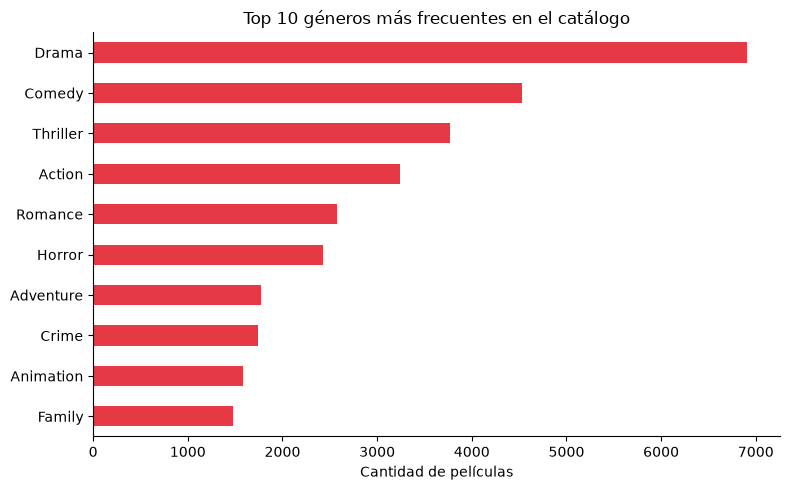

In [11]:

# 3.2 Top 10 géneros más frecuentes
generos = df_clean['genres'].dropna().str.split(', ').explode()
top_generos = generos.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8,5))
top_generos.sort_values().plot(kind='barh', ax=ax, color='#E63946')
ax.set_title('Top 10 géneros más frecuentes en el catálogo')
ax.set_xlabel('Cantidad de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


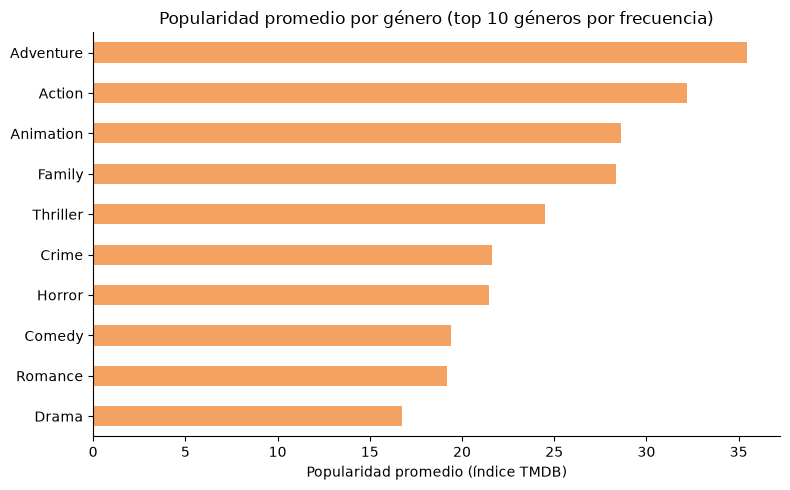

In [12]:

# 3.3 Popularidad promedio por género (top 10 por frecuencia)
df_gen = df_clean[['genres','popularity']].dropna().copy()
df_gen['genres'] = df_gen['genres'].str.split(', ')
df_gen = df_gen.explode('genres')
pop_por_genero = df_gen[df_gen['genres'].isin(top_generos.index)].groupby('genres')['popularity'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,5))
pop_por_genero.plot(kind='barh', ax=ax, color='#F4A261')
ax.set_title('Popularidad promedio por género (top 10 géneros por frecuencia)')
ax.set_xlabel('Popularidad promedio (índice TMDB)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


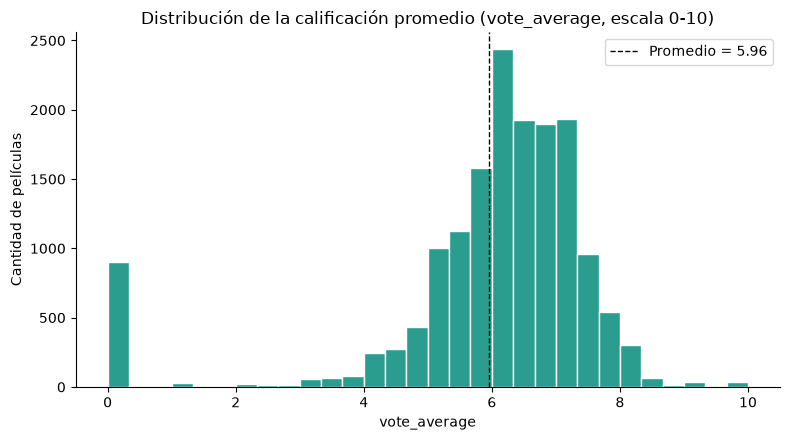

In [13]:

# 3.4 Distribución de vote_average (valoración del público)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(df_clean['vote_average'].dropna(), bins=30, color='#2A9D8F', edgecolor='white')
ax.axvline(df_clean['vote_average'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Promedio = {df_clean['vote_average'].mean():.2f}")
ax.set_title('Distribución de la calificación promedio (vote_average, escala 0-10)')
ax.set_xlabel('vote_average')
ax.set_ylabel('Cantidad de películas')
ax.legend()
plt.tight_layout()
plt.show()


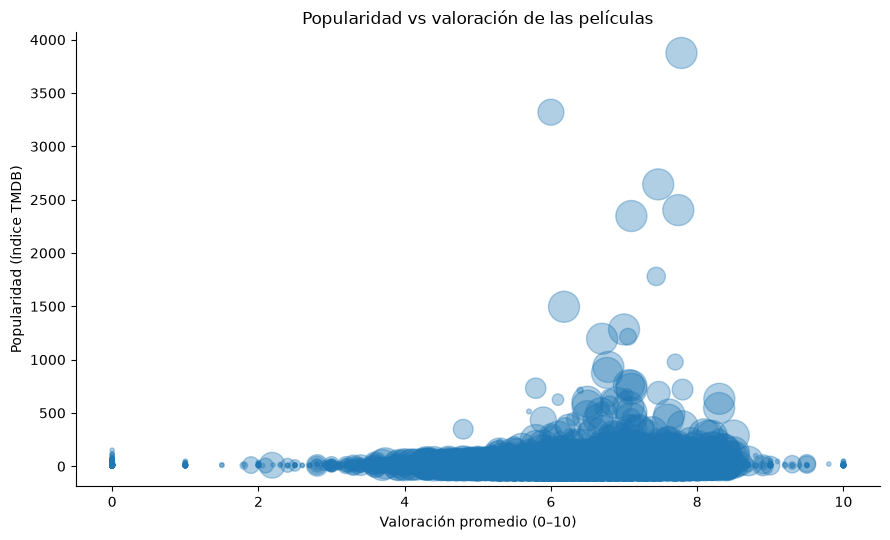

Interpretación: el gráfico permite identificar si las películas más populares también concentran las mejores valoraciones.


In [14]:
# 3.5 Relación entre popularidad y valoración
datos_pop = df_clean.dropna(subset=['popularity', 'vote_average']).copy()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(
    datos_pop['vote_average'],
    datos_pop['popularity'],
    s=np.clip(datos_pop['vote_count'], 10, 500),
    alpha=0.35
)
ax.set_title('Popularidad vs valoración de las películas')
ax.set_xlabel('Valoración promedio (0–10)')
ax.set_ylabel('Popularidad (índice TMDB)')
plt.tight_layout()
plt.show()

print('Interpretación: el gráfico permite identificar si las películas más populares también concentran las mejores valoraciones.')

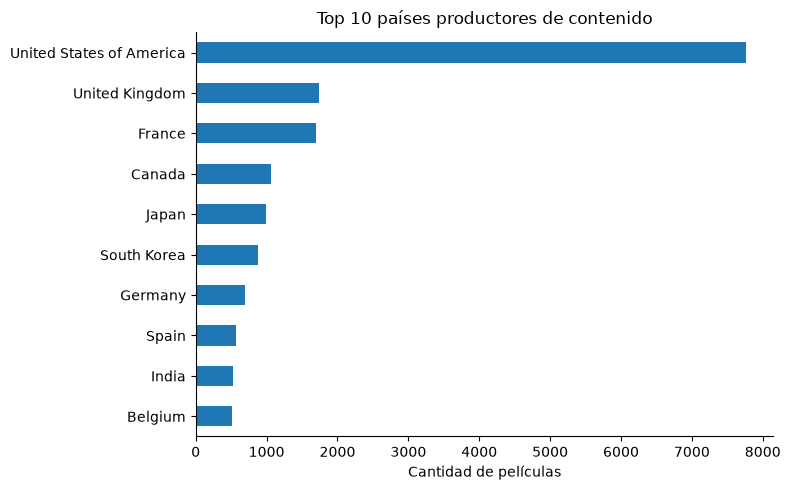

In [15]:
# 3.6 Top 10 países productores
paises = df_clean['country'].dropna().str.split(', ').explode()
top_paises = paises.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_paises.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 países productores de contenido')
ax.set_xlabel('Cantidad de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

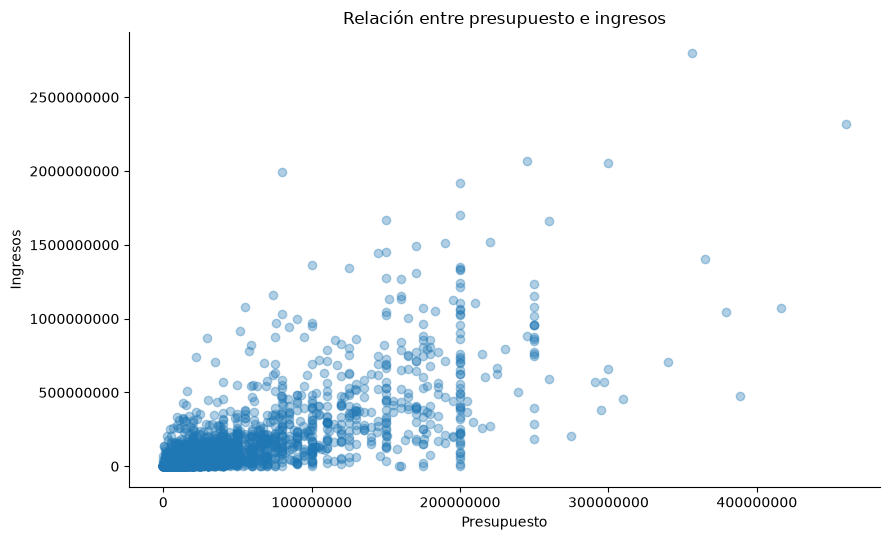

Películas con presupuesto e ingresos disponibles: 3540 (22.1% del catálogo)
⚠️ La lectura financiera representa únicamente el subconjunto con ambos datos disponibles.


In [16]:
# 3.7 Relación presupuesto vs. ingresos
datos_fin = df_clean.dropna(subset=['budget', 'revenue']).copy()
porcentaje_fin = len(datos_fin) / len(df_clean) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(datos_fin['budget'], datos_fin['revenue'], alpha=0.35)
ax.set_title('Relación entre presupuesto e ingresos')
ax.set_xlabel('Presupuesto')
ax.set_ylabel('Ingresos')
ax.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

print(f'Películas con presupuesto e ingresos disponibles: {len(datos_fin)} ({porcentaje_fin:.1f}% del catálogo)')
print('⚠️ La lectura financiera representa únicamente el subconjunto con ambos datos disponibles.')

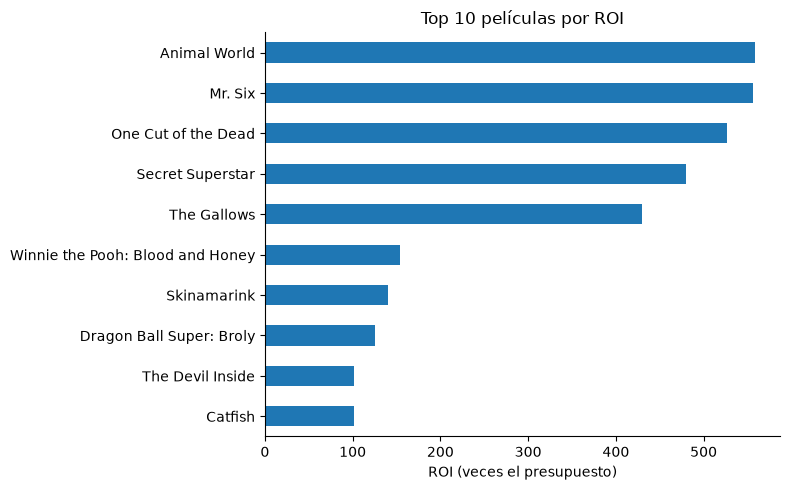

                           title    budget     revenue        roi      roi_pct
                    Animal World  125000.0  69885700.0 559.085600 55808.560000
                         Mr. Six  250000.0 139191345.0 556.765380 55576.538000
             One Cut of the Dead   52406.0  27590180.0 526.469870 52546.986986
                Secret Superstar  286284.0 137416709.0 480.001359 47900.135879
                     The Gallows  100000.0  42964410.0 429.644100 42864.410000
Winnie the Pooh: Blood and Honey   50000.0   7717044.0 154.340880 15334.088000
                     Skinamarink   15000.0   2100000.0 140.000000 13900.000000
        Dragon Ball Super: Broly 1000000.0 125002821.0 125.002821 12400.282100
                The Devil Inside 1000000.0 101800000.0 101.800000 10080.000000
                         Catfish   30000.0   3045943.0 101.531433 10053.143333


In [17]:
# 3.8 Top 10 películas por ROI
top_roi = (
    df_clean.dropna(subset=['roi'])
    .sort_values('roi', ascending=False)
    .head(10)[['title', 'budget', 'revenue', 'roi', 'roi_pct']]
)

top_roi_plot = top_roi.set_index('title')['roi'].sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
top_roi_plot.plot(kind='barh', ax=ax)
ax.set_title('Top 10 películas por ROI')
ax.set_xlabel('ROI (veces el presupuesto)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print(top_roi.to_string(index=False))

## 4. Principales Hallazgos

### Hallazgos de calidad de datos

- `duration` está **100% vacía** en este extracto, por lo que no es posible analizar duración.
- `rating` coincide exactamente con `vote_average`, por lo que **no se utiliza como clasificación por edad**.
- Los valores 0 de `budget` y `revenue` se consideran datos no informados y se transforman en `NaN`.
- Solo una parte del catálogo dispone simultáneamente de presupuesto e ingresos; por eso el análisis financiero tiene alcance parcial.
- No se detectaron duplicados por `show_id`.

### Hallazgos de negocio

- El catálogo contiene aproximadamente 1.000 películas por año entre 2010 y 2025; esta distribución uniforme limita el análisis de tendencias temporales.
- **Drama** es el género con mayor presencia, mientras que **Adventure** presenta la mayor popularidad promedio entre los principales géneros analizados.
- Por lo tanto, **mayor presencia no implica mayor popularidad**, un hallazgo útil para priorización del catálogo.
- Estados Unidos concentra ampliamente la producción del catálogo.
- La relación entre popularidad y valoración permite identificar contenidos que combinan visibilidad e interés del público.
- Existe una relación positiva entre presupuesto e ingresos, aunque con alta dispersión.
- Algunas películas presentan ROI elevado, pero este análisis solo considera los registros con datos financieros utilizables.

## 5. Conclusión del EDA

El análisis exploratorio permite caracterizar el catálogo de StreamView y conectar sus principales dimensiones con las decisiones de negocio. La primera conclusión es que la cantidad de contenidos por sí sola no permite determinar cuáles son las mejores oportunidades: **Drama concentra la mayor presencia, pero Adventure destaca por popularidad promedio**. Esto muestra que la disponibilidad de contenido y su atractivo no son necesariamente equivalentes.

A nivel geográfico, la producción se encuentra fuertemente concentrada en Estados Unidos. Además, la comparación entre popularidad y valoración permite complementar el análisis de frecuencia con una perspectiva de interés del público y facilitar la identificación de películas destacadas.

El componente financiero puede aportar una perspectiva adicional para priorizar contenidos, pero debe interpretarse con cautela porque presupuesto e ingresos están disponibles simultáneamente solo para una parte del catálogo. Por esta razón, el ROI se calcula exclusivamente sobre registros válidos.

### Conexión con el dashboard

Los resultados del EDA se traducen directamente en el dashboard: **presencia de géneros → popularidad por género → países productores → popularidad vs valoración → ranking de películas → análisis financiero**. De esta manera, cada visualización responde a una pregunta de negocio y no se incorpora únicamente con fines decorativos.